# Robust GHZ State Preparation via Majority-Voted Boundary Measurements — Reproduction Notebook

**Paper**: J.-B. Waring, S. Le Beux, C. Pere. *Robust GHZ State Preparation via Majority-Voted Boundary Measurements.* NEWCAS 2026 (Track 17 — Quantum Computing). [arXiv:2602.19405](https://arxiv.org/abs/2602.19405)

## Scope

- **Figure 2(a–c)** – example partitions on Heavy-hex, Grid, and Ring at $N=40$, $K=20$, $L=3$.
- **Figure 2(d)** – large-scale Heavy-hex partition at $N=1000$, $K=125$, $L=3$.
- **Figure 2(e–f)** – entanglement witness $\mathcal{W}_N$ vs. qubit count for Heavy-hex and Grid, $N \in \{30, 40, 50, 60\}$, comparing four methods (Unitary, Line Dynamic, Group-MV $L=1$, Group-MV $L=3$).
- **Fidelity validation table** – stabilizer-sampling fidelity at $N=30$ on Heavy-hex for the Unitary, Line Dynamic, and Group-MV $L=3$ methods.

## How to run this notebook

Set the `MODE` variable in Section 1:

- `"fast"` (default) – reduced shots/trials, renders the full notebook in under ten minutes so reviewers can see the figure shapes and sanity-check the pipeline.
- `"full"` – matches what was done for our paper exactly (30 000 shots, 10 trials, 30 MC stabilizer samples). Expect 1–2 hours on M1 Max or similar with AerSimulator.

## Dependencies

```
qiskit>=2.3,<3.0
qiskit-aer>=0.17
mthree>=2.0
networkx>=3.6
scipy>=1.12
numpy
matplotlib
pandas
```

## Citation

```bibtex
@inproceedings{waring2026ghz,
  author    = {Waring, Jean-Baptiste and Le Beux, S{\'e}bastien and Pere, Christophe},
  title     = {Robust {GHZ} State Preparation via Majority-Voted Boundary Measurements},
  booktitle = {IEEE NEWCAS 2026},
  year      = {2026}
}
```


## 1. Environment setup

Run-mode toggle, seeds, and publication-style Matplotlib defaults.

In [ ]:
# Reproducibility + speed switch
MODE = "full"                  # "fast" (preview) or "full" (reported values)
BASE_SEED = 42

# Noise model parameters
P_CX = 1e-4      # two-qubit depolarizing
P_1Q = 1e-4      # single-qubit depolarizing
P_RO = 0.05      # symmetric readout error

# Experimental configuration
GROUP_SIZE = 20
N_VALUES   = [30, 40, 50, 60]
TOPO_NAMES = ["Heavy-hex", "Grid"]
METHOD_NAMES = ["Unitary", "Line Dynamic", "Group MV L=1", "Group MV L=3"]

# Run-mode dependent knobs
if MODE == "full":
    N_TRIALS          = 10
    SHOTS_WITNESS     = 12_000
    SHOTS_M3_CAL      = 4096
    MC_SAMPLES_FID    = 100      # for the N=30 fidelity validation table
    MC_SHOTS_FID      = 2048
    SEED_POOL_SIZE    = 60
elif MODE == "fast":
    N_TRIALS          = 3
    SHOTS_WITNESS     = 4_000
    SHOTS_M3_CAL      = 2048
    MC_SAMPLES_FID    = 10
    MC_SHOTS_FID      = 512
    SEED_POOL_SIZE    = 20
else:
    raise ValueError(f"Unknown MODE={MODE!r}")

import io
import os
import random
import time
from collections import defaultdict, deque
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon

import networkx as nx
from scipy.spatial import ConvexHull

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.classical import expr
from qiskit.quantum_info import Pauli, Statevector
from qiskit.transpiler import CouplingMap
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError

import mthree

random.seed(BASE_SEED)
np.random.seed(BASE_SEED)

# Publication Matplotlib defaults (shared with our paper's figures)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "font.size": 8,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.format": "pdf",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "legend.framealpha": 1,
    "legend.edgecolor": "0.8",
    "legend.fontsize": 7,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "lines.linewidth": 1.0,
    "lines.markersize": 4,
})
SINGLE_COL = 3.25
DOUBLE_COL = 7.08

METHOD_COLORS = {
    "Unitary":       "#0072B2",
    "Line Dynamic":  "#D55E00",
    "Group MV L=1":  "#009E73",
    "Group MV L=3":  "#CC79A7",
}

print(f"Mode: {MODE}")
print(f"  N_TRIALS={N_TRIALS}, SHOTS_WITNESS={SHOTS_WITNESS}")
print(f"  Noise: p_CX={P_CX}, p_1Q={P_1Q}, p_RO={P_RO}")


Mode: full
  N_TRIALS=10, SHOTS_WITNESS=12000
  Noise: p_CX=0.0001, p_1Q=0.0001, p_RO=0.05


## 2. Hardware topologies

Out paper uses three coupling graphs:

- **Heavy-hex** — an IBM-style heavy-hexagonal lattice (the quantum processor topology used in the fidelity experiments).
- **Grid** — a 2-D square lattice.
- **Ring** — a 1-D closed chain (used only for the partition-visualization panel Fig. 2c).

In [ ]:
# Out paper reuses a single d=7 heavy-hex fabric (115 physical qubits) for the
# Figure-2 scaling sweep (N in {30,40,50,60}). A larger distance is only needed
# for the Figure 2(d) N=1000 visualization.
cm_hh_default = CouplingMap.from_heavy_hex(7)


def heavy_hex_d(n_qubits):
    '''Smallest odd-distance heavy-hex CouplingMap hosting at least n_qubits qubits.'''
    for d in range(3, 60, 2):
        cm = CouplingMap.from_heavy_hex(d)
        if cm.size() >= n_qubits:
            return cm
    raise ValueError(f'No heavy-hex size fits {n_qubits} qubits')


# Grid shapes chosen so that r*c >= N for each N in {30,40,50,60}
GRID_SHAPES = {30: (5, 6), 40: (4, 10), 50: (5, 10), 60: (6, 10)}

def get_topology(name, n):
    if name == "Heavy-hex":
        return cm_hh_default
    if name == "Grid":
        r, c = GRID_SHAPES[n]
        return CouplingMap.from_grid(r, c)
    if name == "Ring":
        return CouplingMap.from_ring(n)
    raise ValueError(f"Unknown topology {name!r}")

print(f"Heavy-hex fabric for Figure 2(e): {cm_hh_default.size()} physical qubits")
for n in N_VALUES:
    r, c = GRID_SHAPES[n]
    print(f"  Grid N={n}: {r} x {c} = {r*c} qubits")


Heavy-hex fabric for Figure 2(e): 115 physical qubits
  Grid N=30: 5 x 6 = 30 qubits
  Grid N=40: 4 x 10 = 40 qubits
  Grid N=50: 5 x 10 = 50 qubits
  Grid N=60: 6 x 10 = 60 qubits


## 3. Logarithmic CNOT-tree GHZ preparation

Our paper's "Unitary" baseline constructs a noise-only GHZ state by growing a breadth-first CNOT tree on the coupling graph — depth $O(\log N)$ — with a Hadamard on the tree root. The same routine is reused intra-group by the Group-MV protocol.

In [3]:
def color_qubits_log(n, coupling_map, available_qubits=None, root=None, m=10, seed=None):
    """BFS CNOT-tree coloring of n qubits.

    Returns (colored, depths, root, cnot_layers) where cnot_layers is a list of
    disjoint-CNOT layers that can execute in parallel.
    """
    G = nx.Graph()
    G.add_edges_from(coupling_map.get_edges())
    adjacency = {node: set(G.neighbors(node)) for node in G.nodes()}
    if seed is not None:
        random.seed(seed)
    if available_qubits is None:
        available_qubits = set(adjacency.keys())
    else:
        available_qubits = set(available_qubits) & set(adjacency.keys())
    if len(available_qubits) < n:
        n = len(available_qubits)

    def build_from_root(start_root):
        colored = [start_root]
        depths = {start_root: 0}
        ready = {start_root}
        cnot_layers = []
        layer = 0
        while len(colored) < n:
            layer += 1
            layer_cnots = []
            used_in_layer = set()
            for ctrl in list(ready):
                if len(colored) >= n:
                    break
                for neighbor in adjacency.get(ctrl, set()):
                    if (neighbor in available_qubits
                        and neighbor not in depths
                        and neighbor not in used_in_layer
                        and ctrl not in used_in_layer):
                        layer_cnots.append((ctrl, neighbor))
                        used_in_layer.add(ctrl)
                        used_in_layer.add(neighbor)
                        colored.append(neighbor)
                        depths[neighbor] = layer
                        break
            if not layer_cnots:
                break
            cnot_layers.append(layer_cnots)
            ready = set(depths.keys())
        return colored, depths, cnot_layers, len(cnot_layers)

    if root is not None:
        if root not in available_qubits:
            raise ValueError(f"Root {root} is not in available qubits")
        colored, depths, cnot_layers, _ = build_from_root(root)
        return colored, depths, root, cnot_layers

    available_list = list(available_qubits)
    best_result = None
    best_depth = float("inf")
    best_root = None
    for _ in range(m):
        candidate_root = random.choice(available_list)
        try:
            colored, depths, cnot_layers, circuit_depth = build_from_root(candidate_root)
            if len(colored) >= n and circuit_depth < best_depth:
                best_depth = circuit_depth
                best_result = (colored[:n], depths, cnot_layers)
                best_root = candidate_root
        except Exception:
            continue
    if best_result is None:
        raise ValueError(f"Could not color {n} qubits after {m} attempts")
    colored, depths, cnot_layers = best_result
    return colored, depths, best_root, cnot_layers


def build_ghz_circuit(colored, root, cnot_layers):
    """Build a unitary GHZ QuantumCircuit from the logarithmic CNOT tree."""
    n_physical = max(colored) + 1
    qc = QuantumCircuit(n_physical, name=f"GHZ_{len(colored)}")
    qc.h(root)
    for layer in cnot_layers:
        for ctrl, tgt in layer:
            qc.cx(ctrl, tgt)
    return qc


def prepare_unitary_ghz(coupling_map, n, seed=42):
    """Build the best-depth LOG-tree GHZ circuit (the 'Unitary' baseline)."""
    colored, _depths, root, layers = color_qubits_log(n, coupling_map, seed=seed)
    circ = build_ghz_circuit(colored, root, layers)
    ghz_qubits = sorted(colored)
    return circ, ghz_qubits


## 4. Line-Dynamic baseline (Bäumer et al., 2023)

Reference 1-D chain protocol: Bell pairs on even sites, CX to bridge sites, measure bridges with cumulative XOR parity correction, then reset and re-entangle the bridges.

In [4]:
def _bell_pair_chain(n):
    """Bell-pair chain on 2n-1 qubits -> n GHZ qubits on even indices."""
    qr = QuantumRegister(2 * n - 1, 'q')
    cr = ClassicalRegister(n, 'c')
    circ = QuantumCircuit(qr, cr)
    for m in range(n):
        circ.h(2 * m)
    for m in range(n - 1):
        circ.cx(2 * m, 2 * m + 1)
    for m in range(n - 1):
        circ.cx(2 * m + 2, 2 * m + 1)
    circ.barrier()
    for m in range(n - 1):
        circ.measure(2 * m + 1, m)
    circ.barrier()
    cond = None
    for m in range(n - 1):
        cond = cr[m] if m == 0 else expr.bit_xor(cond, cr[m])
        with circ.if_test(expr.equal(cond, True)):
            circ.x(2 * m + 2)
    return circ


def construct_line_dynamic(n):
    """Line-Dynamic GHZ on n physical qubits: Bell chain + reset + re-entangle."""
    n0 = int((n + 1) / 2 if n % 2 == 1 else n / 2)
    qr = QuantumRegister(n, 'q')
    cr = ClassicalRegister(n0, 'c')
    circ = QuantumCircuit(qr, cr)
    circ.compose(_bell_pair_chain(n0), qr[0:(2 * n0 - 1)], cr, inplace=True)
    circ.barrier()
    n_reset = n0 - (n % 2)
    for m in range(n_reset):
        circ.reset(2 * m + 1)
    for m in range(n_reset):
        circ.cx(2 * m, 2 * m + 1)
    return circ


def find_path_in_coupling_map(coupling_map, n):
    """Diameter path of length n via double-BFS (greedy DFS fallback)."""
    G = nx.Graph()
    G.add_edges_from(coupling_map.get_edges())
    if G.number_of_nodes() < n:
        raise ValueError(f"Graph has {G.number_of_nodes()} nodes, need {n}")
    start = list(G.nodes())[0]
    lengths = nx.single_source_shortest_path_length(G, start)
    far_node = max(lengths, key=lengths.get)
    lengths2 = nx.single_source_shortest_path_length(G, far_node)
    other_end = max(lengths2, key=lengths2.get)
    diameter_path = nx.shortest_path(G, far_node, other_end)
    if len(diameter_path) >= n:
        return diameter_path[:n]
    path = list(diameter_path)
    visited = set(path)
    while len(path) < n:
        extended = False
        for nb in G.neighbors(path[-1]):
            if nb not in visited:
                path.append(nb); visited.add(nb); extended = True; break
        if not extended:
            for nb in G.neighbors(path[0]):
                if nb not in visited:
                    path.insert(0, nb); visited.add(nb); extended = True; break
        if not extended:
            break
    return path[:n]


def build_line_dynamic_on_coupling_map(coupling_map, n):
    """Map Line-Dynamic circuit onto physical qubits from the topology's diameter path."""
    path = find_path_in_coupling_map(coupling_map, n)
    base_circ = construct_line_dynamic(len(path))
    n_physical = max(path) + 1
    qc = QuantumCircuit(n_physical, name=f"LineDyn_{len(path)}")
    for creg in base_circ.cregs:
        qc.add_register(creg)
    qubit_map = {base_circ.qubits[i]: qc.qubits[path[i]] for i in range(len(path))}
    for instruction in base_circ.data:
        mapped_qubits = [qubit_map[q] for q in instruction.qubits]
        qc.append(instruction.operation, mapped_qubits, instruction.clbits)
    return qc, sorted(path)


## 5. Coupling-graph partitioning (Algorithm 1)

Select $N$ qubits with BFS from a central node, then recursively Kernighan–Lin-bisect into $\lceil N / K \rceil$ balanced, connected groups. Falls back to a BFS-tree cut if KL produces disconnected parts, which never happens on the topologies used here but is included for robustness.

In [5]:
def partition_into_groups(coupling_map, n, group_size, seed=42):
    """Recursive Kernighan-Lin bisection into floor(n / group_size) balanced groups."""
    G = nx.Graph()
    G.add_edges_from(coupling_map.get_edges())
    rng = random.Random(seed)
    nodes = list(G.nodes())
    if not nodes:
        return [], []

    start = rng.choice(nodes)
    lengths = nx.single_source_shortest_path_length(G, start)
    start = sorted(lengths.items(), key=lambda x: x[1])[len(lengths) // 2][0]

    visited, queue, colored = set(), deque([start]), []
    while queue and len(colored) < n:
        node = queue.popleft()
        if node in visited:
            continue
        visited.add(node)
        colored.append(node)
        for nb in sorted(G.neighbors(node)):
            if nb not in visited:
                queue.append(nb)
    colored_set = set(colored)
    subgraph = G.subgraph(colored_set).copy()
    m_groups = max(1, (n + group_size - 1) // group_size)
    if m_groups == 1:
        return [colored_set], colored

    def bisect(node_set):
        sub = subgraph.subgraph(node_set)
        if not nx.is_connected(sub):
            comps = sorted(nx.connected_components(sub), key=len, reverse=True)
            left, right = set(), set()
            for c in comps:
                (left if len(left) <= len(right) else right).update(c)
            return left, right
        try:
            a, b = nx.algorithms.community.kernighan_lin_bisection(sub, seed=seed)
            a, b = set(a), set(b)
            if nx.is_connected(sub.subgraph(a)) and nx.is_connected(sub.subgraph(b)):
                return a, b
        except Exception:
            pass
        # BFS-tree bisection fallback (guarantees connectivity)
        center = max(node_set, key=lambda nd: sub.degree(nd))
        tree = nx.bfs_tree(sub, center)
        best_balance, best_desc = float("inf"), None
        for u, v in tree.edges():
            desc = nx.descendants(tree, v) | {v}
            bal = abs(2 * len(desc) - len(node_set))
            if bal < best_balance:
                best_balance, best_desc = bal, desc
        if best_desc is not None:
            return node_set - best_desc, best_desc
        half = len(node_set) // 2
        ns = list(node_set)
        return set(ns[:half]), set(ns[half:])

    groups = [colored_set]
    while len(groups) < m_groups:
        idx = max(range(len(groups)), key=lambda i: len(groups[i]))
        a, b = bisect(groups[idx])
        groups[idx] = a
        groups.insert(idx + 1, b)
    return [g for g in groups if g], colored


def find_boundary_edges(coupling_map, groups):
    """Coupling-map edges that straddle two different groups."""
    q2g = {q: gid for gid, g in enumerate(groups) for q in g}
    G = nx.Graph(); G.add_edges_from(coupling_map.get_edges())
    out, seen = [], set()
    for u, v in G.edges():
        if u in q2g and v in q2g and q2g[u] != q2g[v]:
            key = (min(q2g[u], q2g[v]), max(q2g[u], q2g[v]),
                   min(u, v), max(u, v))
            if key not in seen:
                seen.add(key)
                out.append({"qubit_a": u, "qubit_b": v,
                            "group_a": q2g[u], "group_b": q2g[v]})
    return out


def get_boundary_pairs_for_groups(boundary_edges):
    """Organize boundary edges by (group_a, group_b) pair."""
    pairs = defaultdict(list)
    for be in boundary_edges:
        key = (min(be["group_a"], be["group_b"]),
               max(be["group_a"], be["group_b"]))
        pairs[key].append((be["qubit_a"], be["qubit_b"]))
    return dict(pairs)


## 6. Group-MV circuit synthesis (Algorithm 2)

Three ingredients:

1. **Parallel local GHZ prep.** Each group runs its own $O(\log K)$ CNOT tree, synchronized across groups with barriers.
2. **Degree-aware spanning-tree boundary allocation.** A two-phase greedy picks edges bridge-first, capping spanning-tree degree at 2 (path-like), then 3, then unbounded. Stage 2 round-robin-augments each boundary up to $L$ edges, skipping qubits already used. The final $L_{\mathrm{eff}}$ per boundary is always odd so that the majority vote has a unique threshold.
3. **Majority-voted classical correction.** Each boundary's $L_{\mathrm{eff}}$ outcomes feed a `majority_expr` (OR of all threshold-sized ANDs). The parent-to-child parity XOR along the group-graph BFS tree is applied as an `if_test` X-gate on a representative qubit of the child group; measured boundary qubits are reset and re-entangled to rejoin the merged GHZ state.

In [6]:
def majority_expr(cr_bits, L):
    """Majority of L classical bits as a Qiskit classical-expression tree:
    OR over all threshold-sized subsets, with AND inside each subset.
    """
    if L == 1:
        return cr_bits[0]
    threshold = (L + 1) // 2
    terms = []
    for combo in combinations(range(L), threshold):
        t = cr_bits[combo[0]]
        for i in combo[1:]:
            t = expr.bit_and(t, cr_bits[i])
        terms.append(t)
    out = terms[0]
    for t in terms[1:]:
        out = expr.bit_or(out, t)
    return out


def build_group_mv_circuit(coupling_map, groups, boundary_pairs,
                           cnot_layers_per_group, roots_per_group, L=1):
    """Algorithm 2: Group-MV GHZ circuit with degree-aware spanning tree
    and in-circuit classical majority + XOR feed-forward corrections."""
    all_qubits = set().union(*groups)
    n_physical = max(all_qubits) + 1
    n_groups = len(groups)

    qr = QuantumRegister(n_physical, 'q')
    qc = QuantumCircuit(qr, name=f"GroupMV_L{L}_{len(all_qubits)}")

    # ---- Step 1: parallel intra-group GHZ prep ----
    for gid in range(n_groups):
        qc.h(roots_per_group[gid])
    max_layers = max((len(l) for l in cnot_layers_per_group), default=0)
    for layer_idx in range(max_layers):
        for gid in range(n_groups):
            if layer_idx < len(cnot_layers_per_group[gid]):
                for ctrl, tgt in cnot_layers_per_group[gid][layer_idx]:
                    qc.cx(ctrl, tgt)

    # ---- Spanning-tree + qubit-exclusive boundary selection ----
    full_gg = nx.Graph()
    for ga, gb in boundary_pairs:
        full_gg.add_edge(ga, gb)
    bridges = set()
    if full_gg.number_of_edges() > 0:
        for u, v in nx.bridges(full_gg):
            bridges.add((min(u, v), max(u, v)))

    uf_parent = list(range(n_groups))
    def uf_find(x):
        while uf_parent[x] != x:
            uf_parent[x] = uf_parent[uf_parent[x]]
            x = uf_parent[x]
        return x
    def uf_union(x, y):
        px, py = uf_find(x), uf_find(y)
        if px != py:
            uf_parent[px] = py

    group_graph = nx.Graph()
    for gid in range(n_groups):
        group_graph.add_node(gid)

    boundary_info = {}
    total_measurements = 0
    used_boundary_qubits = set()
    remaining = dict(boundary_pairs)
    st_degree = [0] * n_groups

    # Stage 1: build spanning tree (1 edge per boundary, bridge-first, degree-aware)
    for phase in ("bridges", "non_bridges"):
        for max_deg in [2, 3, n_groups]:
            changed = True
            while changed and len(boundary_info) < n_groups - 1:
                changed = False
                best_key, best_avail, best_score = None, None, (float("inf"), float("inf"))
                for (ga, gb), edges in remaining.items():
                    key = (min(ga, gb), max(ga, gb))
                    is_bridge = key in bridges
                    if phase == "bridges" and not is_bridge:  continue
                    if phase == "non_bridges" and is_bridge:  continue
                    if uf_find(ga) == uf_find(gb):            continue
                    if st_degree[ga] >= max_deg or st_degree[gb] >= max_deg:
                        continue
                    avail = [(a, b) for a, b in edges
                             if a not in used_boundary_qubits and b not in used_boundary_qubits]
                    if not avail:
                        continue
                    score = (max(st_degree[ga], st_degree[gb]), len(avail))
                    if score < best_score:
                        best_score, best_key, best_avail = score, (ga, gb), avail
                if best_key is not None:
                    ga, gb = best_key
                    qa, qb = best_avail[0]
                    used_boundary_qubits.update({qa, qb})
                    uf_union(ga, gb)
                    group_graph.add_edge(ga, gb)
                    st_degree[ga] += 1
                    st_degree[gb] += 1
                    total_measurements += 1
                    boundary_info[(ga, gb)] = {
                        "links": [(qa, qb)], "L_eff": 1,
                        "measured_qubits": [qb],
                    }
                    del remaining[best_key]
                    changed = True

    # Stage 2: round-robin augmentation up to L
    if L > 1:
        augmented = True
        while augmented:
            augmented = False
            for (ga, gb), info in sorted(boundary_info.items()):
                if info["L_eff"] >= L:
                    continue
                src = boundary_pairs.get((ga, gb), boundary_pairs.get((gb, ga), []))
                local_used = {q for pair in info["links"] for q in pair}
                for qa, qb in src:
                    if (qa not in used_boundary_qubits and qb not in used_boundary_qubits
                            and qa not in local_used and qb not in local_used):
                        info["links"].append((qa, qb))
                        info["measured_qubits"].append(qb)
                        used_boundary_qubits.update({qa, qb})
                        info["L_eff"] += 1
                        total_measurements += 1
                        augmented = True
                        break

    # Enforce odd L_eff (even L has no symmetric majority threshold)
    for info in boundary_info.values():
        while info["L_eff"] > 1 and info["L_eff"] % 2 == 0:
            qa, qb = info["links"].pop()
            info["measured_qubits"].pop()
            used_boundary_qubits.discard(qa)
            used_boundary_qubits.discard(qb)
            info["L_eff"] -= 1
            total_measurements -= 1

    if total_measurements == 0:
        return qc, sorted(all_qubits), set(), {}

    root_group = 0
    bfs_order = list(nx.bfs_edges(group_graph, root_group))

    # Normalize link directions so qb is in the child group along the BFS tree
    for parent_g, child_g in bfs_order:
        key = (min(parent_g, child_g), max(parent_g, child_g))
        info = boundary_info[key]
        nl, nm = [], []
        for qa, qb in info["links"]:
            if qb in groups[child_g]:
                nl.append((qa, qb)); nm.append(qb)
            else:
                nl.append((qb, qa)); nm.append(qa)
        info["links"] = nl
        info["measured_qubits"] = nm

    # ---- Step 2: boundary CNOTs ----
    for (ga, gb), info in sorted(boundary_info.items()):
        for qa, qb in info["links"]:
            qc.cx(qa, qb)
    qc.barrier()

    # ---- Step 3: measure all boundary qubits ----
    cr_bnd = ClassicalRegister(total_measurements, "bnd")
    qc.add_register(cr_bnd)
    cr_offset = 0
    for (ga, gb), info in sorted(boundary_info.items()):
        info["cr_indices"] = list(range(cr_offset, cr_offset + info["L_eff"]))
        for i, (_, qb) in enumerate(info["links"]):
            qc.measure(qb, cr_bnd[cr_offset + i])
        cr_offset += info["L_eff"]
    qc.barrier()

    # ---- Step 4: classical majority + XOR feed-forward corrections ----
    all_measured = set().union(*(set(info["measured_qubits"]) for info in boundary_info.values()))
    group_parity_expr = {}
    for parent_g, child_g in bfs_order:
        key = (min(parent_g, child_g), max(parent_g, child_g))
        info = boundary_info[key]
        cr_bits = [cr_bnd[i] for i in info["cr_indices"]]
        voted = majority_expr(cr_bits, info["L_eff"])
        if parent_g in group_parity_expr:
            cumulative = expr.bit_xor(group_parity_expr[parent_g], voted)
        else:
            cumulative = voted
        group_parity_expr[child_g] = cumulative
        correction_qubits = sorted(groups[child_g] - all_measured)
        if correction_qubits:
            with qc.if_test(expr.equal(cumulative, True)):
                for q in correction_qubits:
                    qc.x(q)
    qc.barrier()

    # ---- Step 5: reset + re-entangle boundary qubits ----
    for (ga, gb), info in sorted(boundary_info.items()):
        for qa, qb in info["links"]:
            qc.reset(qb)
            qc.cx(qa, qb)

    return qc, sorted(all_qubits), all_measured, boundary_info


def build_group_ghz(coupling_map, groups, L=1, seed=42):
    """Wrap build_group_mv_circuit with per-group CNOT-tree construction."""
    cnot_layers_per_group = []
    roots_per_group = []
    for group in groups:
        sub_edges = [(u, v) for u, v in coupling_map.get_edges()
                     if u in group and v in group]
        if not sub_edges:
            roots_per_group.append(min(group))
            cnot_layers_per_group.append([])
            continue
        sub_cm = CouplingMap(sub_edges + [(v, u) for u, v in sub_edges])
        _, _, r, lyr = color_qubits_log(
            len(group), sub_cm, available_qubits=group, seed=seed, m=20)
        roots_per_group.append(r)
        cnot_layers_per_group.append(lyr)
    b_edges = find_boundary_edges(coupling_map, groups)
    b_pairs = get_boundary_pairs_for_groups(b_edges)
    circuit, ghz_qubits, _measured, binfo = build_group_mv_circuit(
        coupling_map, groups, b_pairs,
        cnot_layers_per_group, roots_per_group, L=L)
    return circuit, ghz_qubits, binfo


## 7. Partition seed search

Different seeds produce different KL bisections. For Group-MV $L=3$ to actually hit $L_{\mathrm{eff}}=3$ on every boundary, we pre-screen seeds on each (topology, $N$) and keep those that achieve the required minimum. Sparse topologies (Heavy-hex) often need tens of seeds before finding a valid one.

In [7]:
def find_valid_partition_seeds(coupling_map, n, group_size, L_target,
                                pool_size=SEED_POOL_SIZE, search_start=BASE_SEED):
    """Scan seeds for partitions with min L_eff >= L_target; return sorted list."""
    G_hw = nx.Graph()
    G_hw.add_edges_from(coupling_map.get_edges())
    valid = []
    for s in range(search_start, search_start + pool_size):
        try:
            groups_s, _ = partition_into_groups(coupling_map, n, group_size, seed=s)
            if len(groups_s) < 2:
                continue
            b_edges_s = find_boundary_edges(coupling_map, groups_s)
            b_pairs_s = get_boundary_pairs_for_groups(b_edges_s)
            cnot_layers_s, roots_s = [], []
            for g in groups_s:
                if len(g) == 1:
                    roots_s.append(next(iter(g))); cnot_layers_s.append([])
                    continue
                sub_edges = [(u, v) for u, v in G_hw.edges() if u in g and v in g]
                if not sub_edges:
                    roots_s.append(next(iter(g))); cnot_layers_s.append([])
                    continue
                sub_cm = CouplingMap(sub_edges + [(v, u) for u, v in sub_edges])
                _, _, r, lyr = color_qubits_log(
                    len(g), sub_cm, available_qubits=g, seed=s, m=20)
                roots_s.append(r); cnot_layers_s.append(lyr)
            _, _, _, binfo = build_group_mv_circuit(
                coupling_map, groups_s, b_pairs_s,
                cnot_layers_s, roots_s, L=L_target)
            min_leff = min(info["L_eff"] for info in binfo.values()) if binfo else 0
            valid.append((s, min_leff))
        except Exception:
            continue
    valid.sort(key=lambda x: (-min(x[1], L_target), x[0]))
    return valid


## 8. Paper noise model

Pauli depolarizing errors on `cx` (2-qubit) and `h`, `x` (1-qubit) gates, plus a symmetric readout error for M3 compatibility.

In [8]:
def make_paper_noise_model(p_cx=P_CX, p_1q=P_1Q, p_ro=P_RO):
    """Paper noise model: depolarizing on CX/H/X + symmetric readout error."""
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p_cx, 2), ['cx'])
    nm.add_all_qubit_quantum_error(depolarizing_error(p_1q, 1), ['h', 'x'])
    nm.add_all_qubit_readout_error(
        ReadoutError([[1 - p_ro, p_ro], [p_ro, 1 - p_ro]]))
    return nm


## 9. Entanglement witness $\mathcal{W}_N$

Paper definition (Eq. 2):
$$
\mathcal{W}_N(\rho) = \tfrac{1}{2}\!\left(P_{|0\rangle^{\otimes N}} + P_{|1\rangle^{\otimes N}} + \langle X^{\otimes N}\rangle\right)
$$

Threshold for genuine $N$-partite entanglement: $\mathcal{W}_N > 0.5$. Computed from two runs: Z-basis (for the population terms) and X-basis (for the parity expectation). M3 readout-error mitigation is applied to both measurements.

In [9]:
def _measure_ghz(circuit, ghz_qubits, basis='Z'):
    qc = circuit.copy()
    sq = sorted(ghz_qubits)
    cr = ClassicalRegister(len(sq), 'out')
    qc.add_register(cr)
    if basis == 'X':
        for q in sq:
            qc.h(q)
    for i, q in enumerate(sq):
        qc.measure(q, cr[i])
    return qc


def _marginalize_out(counts):
    """Keep only the 'out' register bits (which appear leftmost in Qiskit bitstrings)."""
    out = {}
    for key, val in counts.items():
        out_key = key.split(' ')[0]
        out[out_key] = out.get(out_key, 0) + val
    return out


def estimate_witness(circuit, ghz_qubits, noise_model=None,
                     shots=SHOTS_WITNESS, m3_mit=None):
    """Entanglement witness W_N = (P(|0>^n) + P(|1>^n) + <X^n>) / 2."""
    n_q = len(ghz_qubits)
    sq = sorted(ghz_qubits)
    sim = AerSimulator(method='stabilizer')
    run_kw = dict(shots=shots)
    if noise_model is not None:
        run_kw['noise_model'] = noise_model

    def _run(basis):
        qc = _measure_ghz(circuit, ghz_qubits, basis)
        raw = _marginalize_out(sim.run(qc, **run_kw).result().get_counts())
        if m3_mit is not None:
            quasi = m3_mit.apply_correction(raw, qubits=sq)
            probs = quasi.nearest_probability_distribution()
            return {k: v * shots for k, v in probs.items()}
        return raw

    z = _run('Z'); tz = sum(z.values())
    p00 = z.get('0' * n_q, 0) / tz
    p11 = z.get('1' * n_q, 0) / tz
    x = _run('X'); tx = sum(x.values())
    x_par = sum(v * (1 if k.count('1') % 2 == 0 else -1) for k, v in x.items()) / tx
    W = 0.5 * (p00 + p11 + x_par)
    se = float(np.sqrt(max(W * (1 - W), 0) / shots))
    return dict(witness=float(W), witness_err=se,
                p00=float(p00), p11=float(p11), x_parity=float(x_par))


## 10. Stabilizer-sampling fidelity

We corroborate the witness $\mathcal{W}$ with a direct fidelity
estimate via stabilizer sampling. We sample random elements of the GHZ
stabilizer group, measure their expectation values, and average. This
complements the witness — where $F \geq 2\mathcal{W} - 1$ — with an
independent and tighter lower bound.

In [10]:
def ghz_stabilizer_generators(n):
    """n generators of the GHZ stabilizer group: Z_i Z_{i+1} (i=0..n-2), X^{otimes n}."""
    gens = []
    for i in range(n - 1):
        label = ['I'] * n
        label[i] = 'Z'; label[i + 1] = 'Z'
        gens.append(Pauli(''.join(reversed(label))))
    gens.append(Pauli('X' * n))
    return gens


def sample_ghz_stabilizer(gens, rng):
    subset = rng.integers(0, 2, size=len(gens))
    result = Pauli('I' * gens[0].num_qubits)
    for j, b in enumerate(subset):
        if b:
            result = result.compose(gens[j])
    return result


def _pauli_measurement_circuit(state_prep_circuit, pauli, ghz_qubits):
    """Append basis rotations + measurements for a Pauli on ghz_qubits.
    The 'stab' register is added LAST (so its bits are the leftmost segment of
    the Qiskit bitstring)."""
    qc = state_prep_circuit.copy()
    n = pauli.num_qubits
    positions = [j for j in range(n) if pauli.x[j] or pauli.z[j]]
    if not positions:
        cr = ClassicalRegister(1, 'stab'); qc.add_register(cr)
        return qc, 1
    qc.barrier()
    for j in positions:
        phys = ghz_qubits[j]
        if pauli.x[j] and not pauli.z[j]:
            qc.h(phys)
        elif pauli.x[j] and pauli.z[j]:
            qc.sdg(phys); qc.h(phys)
    cr = ClassicalRegister(len(positions), 'stab')
    qc.add_register(cr)
    for i, j in enumerate(positions):
        qc.measure(ghz_qubits[j], cr[i])
    return qc, len(positions)


def mc_ghz_fidelity(state_prep_circuit, n_ghz, ghz_qubits,
                    m_samples=MC_SAMPLES_FID, shots_per_stabilizer=MC_SHOTS_FID,
                    noise_model=None, seed=BASE_SEED, m3_mitigate=False):
    """GHZ fidelity F = <psi_GHZ|rho|psi_GHZ> via stabilizer sampling.

    Returns dict(fidelity, std_error, samples)."""
    rng = np.random.default_rng(seed)
    gens = ghz_stabilizer_generators(n_ghz)

    backend_kw = dict(method='stabilizer')
    if noise_model is not None:
        backend_kw['noise_model'] = noise_model
    backend = AerSimulator(**backend_kw)

    m3_mit = None
    if m3_mitigate:
        m3_mit = mthree.M3Mitigation(backend)
        m3_mit.cals_from_system(
            qubits=list(range(state_prep_circuit.num_qubits)),
            shots=SHOTS_M3_CAL)

    expectations = []
    for _ in range(m_samples):
        stab = sample_ghz_stabilizer(gens, rng)
        if not any(stab.x[j] or stab.z[j] for j in range(n_ghz)):
            expectations.append(1.0); continue
        meas_circ, n_stab_bits = _pauli_measurement_circuit(
            state_prep_circuit, stab, ghz_qubits)
        try:
            counts = backend.run(meas_circ, shots=shots_per_stabilizer).result().get_counts()
            if m3_mit is not None:
                clbit2q = {}
                for inst in meas_circ.data:
                    if inst.operation.name == 'measure':
                        qi = meas_circ.find_bit(inst.qubits[0]).index
                        ci = meas_circ.find_bit(inst.clbits[0]).index
                        clbit2q[ci] = qi
                mapping = [clbit2q.get(i, 0) for i in range(meas_circ.num_clbits)]
                counts_ns = {k.replace(' ', ''): v for k, v in counts.items()}
                quasis = m3_mit.apply_correction(counts_ns, mapping)
                counts = {k: max(0.0, v) for k, v in quasis.items()}
                total = sum(counts.values())
                if total > 0:
                    counts = {k: v / total * shots_per_stabilizer for k, v in counts.items()}
            even = odd = 0
            for bitstring, count in counts.items():
                stab_bits = bitstring.replace(' ', '')[:n_stab_bits]
                if stab_bits.count('1') % 2 == 0:
                    even += count
                else:
                    odd += count
            total = even + odd
            raw = (even - odd) / total if total > 0 else 0.0
            sign = (-1) ** (stab.phase // 2)
            expectations.append(sign * raw)
        except Exception:
            continue
    if not expectations:
        return dict(fidelity=float('nan'), std_error=float('nan'), samples=[])
    fidelity = float(np.mean(expectations))
    std_error = float(np.std(expectations, ddof=1) / np.sqrt(len(expectations)))
    return dict(fidelity=fidelity, std_error=std_error, samples=expectations)


## 11. Figure 2 — combined topology partitions (a–d) and witness scaling (e–f)

A single 12-subplot figure reproducing our paper's Figure 2:

**Top row (a–d):** Example partitions for $N=40$, $K=20$, $L=3$ on Heavy-hex,
Grid, Ring, plus a large-scale Heavy-hex with $N=1000$, $K=125$, $L=3$.
Cluster qubits are colored by group; red edges mark the inter-cluster boundary
links (where majority voting is performed). The Ring topology has minimum
$L_{\mathrm{eff}}=1$ — the protocol auto-reduces $L$ to fit topological
constraints.

**Middle and bottom rows (e–f):** Entanglement witness $\mathcal{W}$ as a
function of GHZ size $N\in\{30,40,50,60\}$ for two topologies (Heavy-hex,
Grid), comparing four methods (Unitary, Line-Dynamic, Group-MV $L=1$,
Group-MV $L=3$). $N_{\text{TRIALS}}$ trials per cell, error bars are 1σ
across trials.

In [11]:
# Topology visualization (panels a-d): per-subplot layout function.
# Adapted from `ghz_group/figure_partition_compare.ipynb`.
def visualize_groups(G, groups, boundary_edges, boundary_info=None,
                       title=None, ax=None, layout_fn=None, node_size=80):
    """Draw topology graph cropped to grouped qubits only.

    layout_fn: callable G -> dict[node, (x, y)]; if None uses kamada_kawai_layout.
    """
    all_grouped = set().union(*groups) if groups else set()
    G_sub = G.subgraph(all_grouped)
    pos = layout_fn(G_sub) if layout_fn is not None else nx.kamada_kawai_layout(G_sub)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    palette = ["#96CEB4", "#85C1E9", "#F4A261", "#B388EB", "#F28B82",
               "#A8D8EA", "#FFD166", "#C4E17F", "#E8A0BF", "#76C7C0"]
    group_colors = [palette[i % len(palette)] for i in range(len(groups))]

    # Intra-group edges (same color as group)
    for gid, group in enumerate(groups):
        intra = [(u, v) for u, v in G_sub.edges() if u in group and v in group]
        if intra:
            nx.draw_networkx_edges(G_sub, pos, edgelist=intra,
                                    edge_color=group_colors[gid], width=2,
                                    alpha=0.4, ax=ax)

    # Boundary edges: tree-selected (red), non-tree (gray dotted)
    tree_edge_set = set()
    if boundary_info:
        for (ga, gb), info in boundary_info.items():
            for qa, qb in info.get("links", []):
                tree_edge_set.add((min(qa, qb), max(qa, qb)))

    tree_draw, nontree_draw = [], []
    for be in boundary_edges:
        qa, qb = be["qubit_a"], be["qubit_b"]
        key = (min(qa, qb), max(qa, qb))
        (tree_draw if key in tree_edge_set else nontree_draw).append((qa, qb))

    if tree_draw:
        w = 5 if len(G_sub.nodes) > 100 else 3
        nx.draw_networkx_edges(G_sub, pos, edgelist=tree_draw,
                                edge_color="red", width=w, ax=ax)
    if nontree_draw:
        nx.draw_networkx_edges(G_sub, pos, edgelist=nontree_draw,
                                edge_color="gray", width=2, alpha=0.3,
                                style="solid", ax=ax)

    # Nodes
    node_color = {q: group_colors[gid]
                   for gid, group in enumerate(groups) for q in group}
    node_list = list(G_sub.nodes())
    nx.draw_networkx_nodes(G_sub, pos, nodelist=node_list,
                            node_color=[node_color.get(q, "lightgray") for q in node_list],
                            node_size=node_size, ax=ax,
                            edgecolors="black", linewidths=0.3)

    if title:
        ax.set_title(title, fontsize=8)
    ax.axis("off")


In [12]:
# Build the per-topology data needed for panels (a)-(d).
# We compute partitions and boundary info; the actual drawing happens in the
# combined figure cell at the end.
_panel_topos = [
    ("Heavy Hex",        cm_hh_default,                        40,   GROUP_SIZE, 3, BASE_SEED + 1, nx.kamada_kawai_layout),
    ("Grid",             CouplingMap.from_grid(4, 10),         40,   GROUP_SIZE, 3, BASE_SEED + 12, nx.kamada_kawai_layout),
    ("Ring",             CouplingMap.from_ring(40),            40,   GROUP_SIZE, 1, BASE_SEED,      nx.circular_layout),
    ("Heavy Hex (1000)", heavy_hex_d(1000),                    1000, 125,        3, BASE_SEED + 2, nx.kamada_kawai_layout),
]

_panel_data = []   # list of dict per panel
for (name, cm, n, k, L_target, seed, layout_fn) in _panel_topos:
    print(f"  Building panel: {name} (N={n}, K={k}, L={L_target}) ...", flush=True)
    valid = find_valid_partition_seeds(cm, n, k, L_target=L_target,
                                         pool_size=SEED_POOL_SIZE)
    seed_used = valid[0][0] if valid else seed
    groups, _ = partition_into_groups(cm, n, k, seed=seed_used)
    b_edges = find_boundary_edges(cm, groups)
    try:
        _, _, b_info = build_group_ghz(cm, groups, L=L_target, seed=seed_used)
    except Exception as ex:
        print(f"    (build_group_ghz failed: {ex})")
        b_info = {}
    G_hw = nx.Graph(); G_hw.add_edges_from(cm.get_edges())
    _panel_data.append({
        "name": name, "n": n, "k": k, "L": L_target,
        "G_hw": G_hw, "groups": groups, "b_edges": b_edges, "b_info": b_info,
        "layout_fn": layout_fn,
    })

print(f"Computed {len(_panel_data)} panel partitions")


  Building panel: Heavy Hex (N=40, K=20, L=3) ...
  Building panel: Grid (N=40, K=20, L=3) ...
  Building panel: Ring (N=40, K=20, L=1) ...
  Building panel: Heavy Hex (1000) (N=1000, K=125, L=3) ...
Computed 4 panel partitions


In [13]:
# Pre-screen partition seeds for each (topology, N), for both L=1 and L=3
print(f"Seed-pool search ({SEED_POOL_SIZE} seeds per (topology, N))...")
_seed_pools = {}
_t_seed = time.time()
for n_val in N_VALUES:
    for topo_name in TOPO_NAMES:
        cm = get_topology(topo_name, n_val)
        l1_seeds = [s for s, _ in find_valid_partition_seeds(
                        cm, n_val, GROUP_SIZE, L_target=1, pool_size=SEED_POOL_SIZE)]
        l3_full = find_valid_partition_seeds(
            cm, n_val, GROUP_SIZE, L_target=3, pool_size=SEED_POOL_SIZE)
        l3_seeds = [s for s, leff in l3_full if leff >= 3]
        _seed_pools[(topo_name, n_val)] = {
            "l1": l1_seeds[:max(N_TRIALS, 5)],
            "l3": l3_seeds[:max(N_TRIALS, 5)],
        }
        print(f"  {topo_name:10s} N={n_val}: {len(l1_seeds)} L=1 seeds, "
              f"{len(l3_seeds)} L=3-valid seeds (need {N_TRIALS})")
print(f"Seed search: {time.time() - _t_seed:.1f}s")


Seed-pool search (60 seeds per (topology, N))...
  Heavy-hex  N=30: 60 L=1 seeds, 17 L=3-valid seeds (need 10)
  Grid       N=30: 60 L=1 seeds, 60 L=3-valid seeds (need 10)
  Heavy-hex  N=40: 60 L=1 seeds, 43 L=3-valid seeds (need 10)
  Grid       N=40: 60 L=1 seeds, 60 L=3-valid seeds (need 10)
  Heavy-hex  N=50: 60 L=1 seeds, 12 L=3-valid seeds (need 10)
  Grid       N=50: 60 L=1 seeds, 25 L=3-valid seeds (need 10)
  Heavy-hex  N=60: 60 L=1 seeds, 16 L=3-valid seeds (need 10)
  Grid       N=60: 60 L=1 seeds, 48 L=3-valid seeds (need 10)
Seed search: 5.3s


In [ ]:
# Noise model and simulators (shared across all trials)
_nm = make_paper_noise_model()
_sim_noiseless = AerSimulator(method='stabilizer')

# M3 calibration backend (one per run)
_cal_backend = AerSimulator(noise_model=_nm, method='stabilizer')
_mit = mthree.M3Mitigation(_cal_backend)

all_trials = defaultdict(list)

t_sweep = time.time()
_trial_seeds = list(range(BASE_SEED, BASE_SEED + N_TRIALS))

for n_val in N_VALUES:
    for topo_name in TOPO_NAMES:
        cm = get_topology(topo_name, n_val)
        pool = _seed_pools[(topo_name, n_val)]
        print(f"\n=== {topo_name} N={n_val} ({N_TRIALS} trials) ===")
        for ti in range(N_TRIALS):
            ts = _trial_seeds[ti]
            t0 = time.time()
            methods = {}

            circ_u, ghz_u = prepare_unitary_ghz(cm, n_val, seed=ts)
            methods['Unitary'] = (circ_u, ghz_u)

            circ_ld, ghz_ld = build_line_dynamic_on_coupling_map(cm, n_val)
            methods['Line Dynamic'] = (circ_ld, ghz_ld)

            if pool['l1']:
                ps_l1 = pool['l1'][ti % len(pool['l1'])]
                g_l1, _ = partition_into_groups(cm, n_val, GROUP_SIZE, seed=ps_l1)
                circ_g1, ghz_g1, _ = build_group_ghz(cm, g_l1, L=1, seed=ts)
                methods['Group MV L=1'] = (circ_g1, ghz_g1)
            if pool['l3']:
                ps_l3 = pool['l3'][ti % len(pool['l3'])]
                g_l3, _ = partition_into_groups(cm, n_val, GROUP_SIZE, seed=ps_l3)
                circ_g3, ghz_g3, _ = build_group_ghz(cm, g_l3, L=3, seed=ts)
                methods['Group MV L=3'] = (circ_g3, ghz_g3)

            # M3 calibration — over the union of all GHZ qubit sets
            sq_union = sorted(set().union(*(set(g) for _, g in methods.values())))
            _mit.cals_from_system(qubits=sq_union, shots=SHOTS_M3_CAL)

            row = {}
            for mname, (circ, ghz) in methods.items():
                r = estimate_witness(circ, ghz, noise_model=_nm,
                                      shots=SHOTS_WITNESS, m3_mit=_mit)
                r['trial'] = ti
                all_trials[(topo_name, n_val, mname)].append(r)
                row[mname] = r['witness']
            dt = time.time() - t0
            fids_str = ", ".join(f"{m}={v:.3f}" for m, v in row.items())
            print(f"  Trial {ti:2d}/{N_TRIALS} ({dt:5.1f}s): {fids_str}")

print(f"\nTotal sweep time: {(time.time() - t_sweep)/60:.1f} min")



=== Heavy-hex N=30 (10 trials) ===
  Trial  0/10 ( 28.8s): Unitary=0.429, Line Dynamic=0.215, Group MV L=1=0.422, Group MV L=3=0.426
  Trial  1/10 ( 25.8s): Unitary=0.433, Line Dynamic=0.227, Group MV L=1=0.415, Group MV L=3=0.441
  Trial  2/10 ( 30.3s): Unitary=0.440, Line Dynamic=0.223, Group MV L=1=0.395, Group MV L=3=0.407
  Trial  3/10 ( 22.8s): Unitary=0.422, Line Dynamic=0.217, Group MV L=1=0.427, Group MV L=3=0.442
  Trial  4/10 ( 25.3s): Unitary=0.432, Line Dynamic=0.213, Group MV L=1=0.411, Group MV L=3=0.415
  Trial  5/10 ( 22.3s): Unitary=0.442, Line Dynamic=0.209, Group MV L=1=0.400, Group MV L=3=0.434
  Trial  6/10 ( 18.9s): Unitary=0.432, Line Dynamic=0.210, Group MV L=1=0.397, Group MV L=3=0.420
  Trial  7/10 ( 21.0s): Unitary=0.432, Line Dynamic=0.212, Group MV L=1=0.414, Group MV L=3=0.430
  Trial  8/10 ( 19.2s): Unitary=0.425, Line Dynamic=0.219, Group MV L=1=0.418, Group MV L=3=0.414
  Trial  9/10 ( 18.3s): Unitary=0.449, Line Dynamic=0.224, Group MV L=1=0.401, Gro

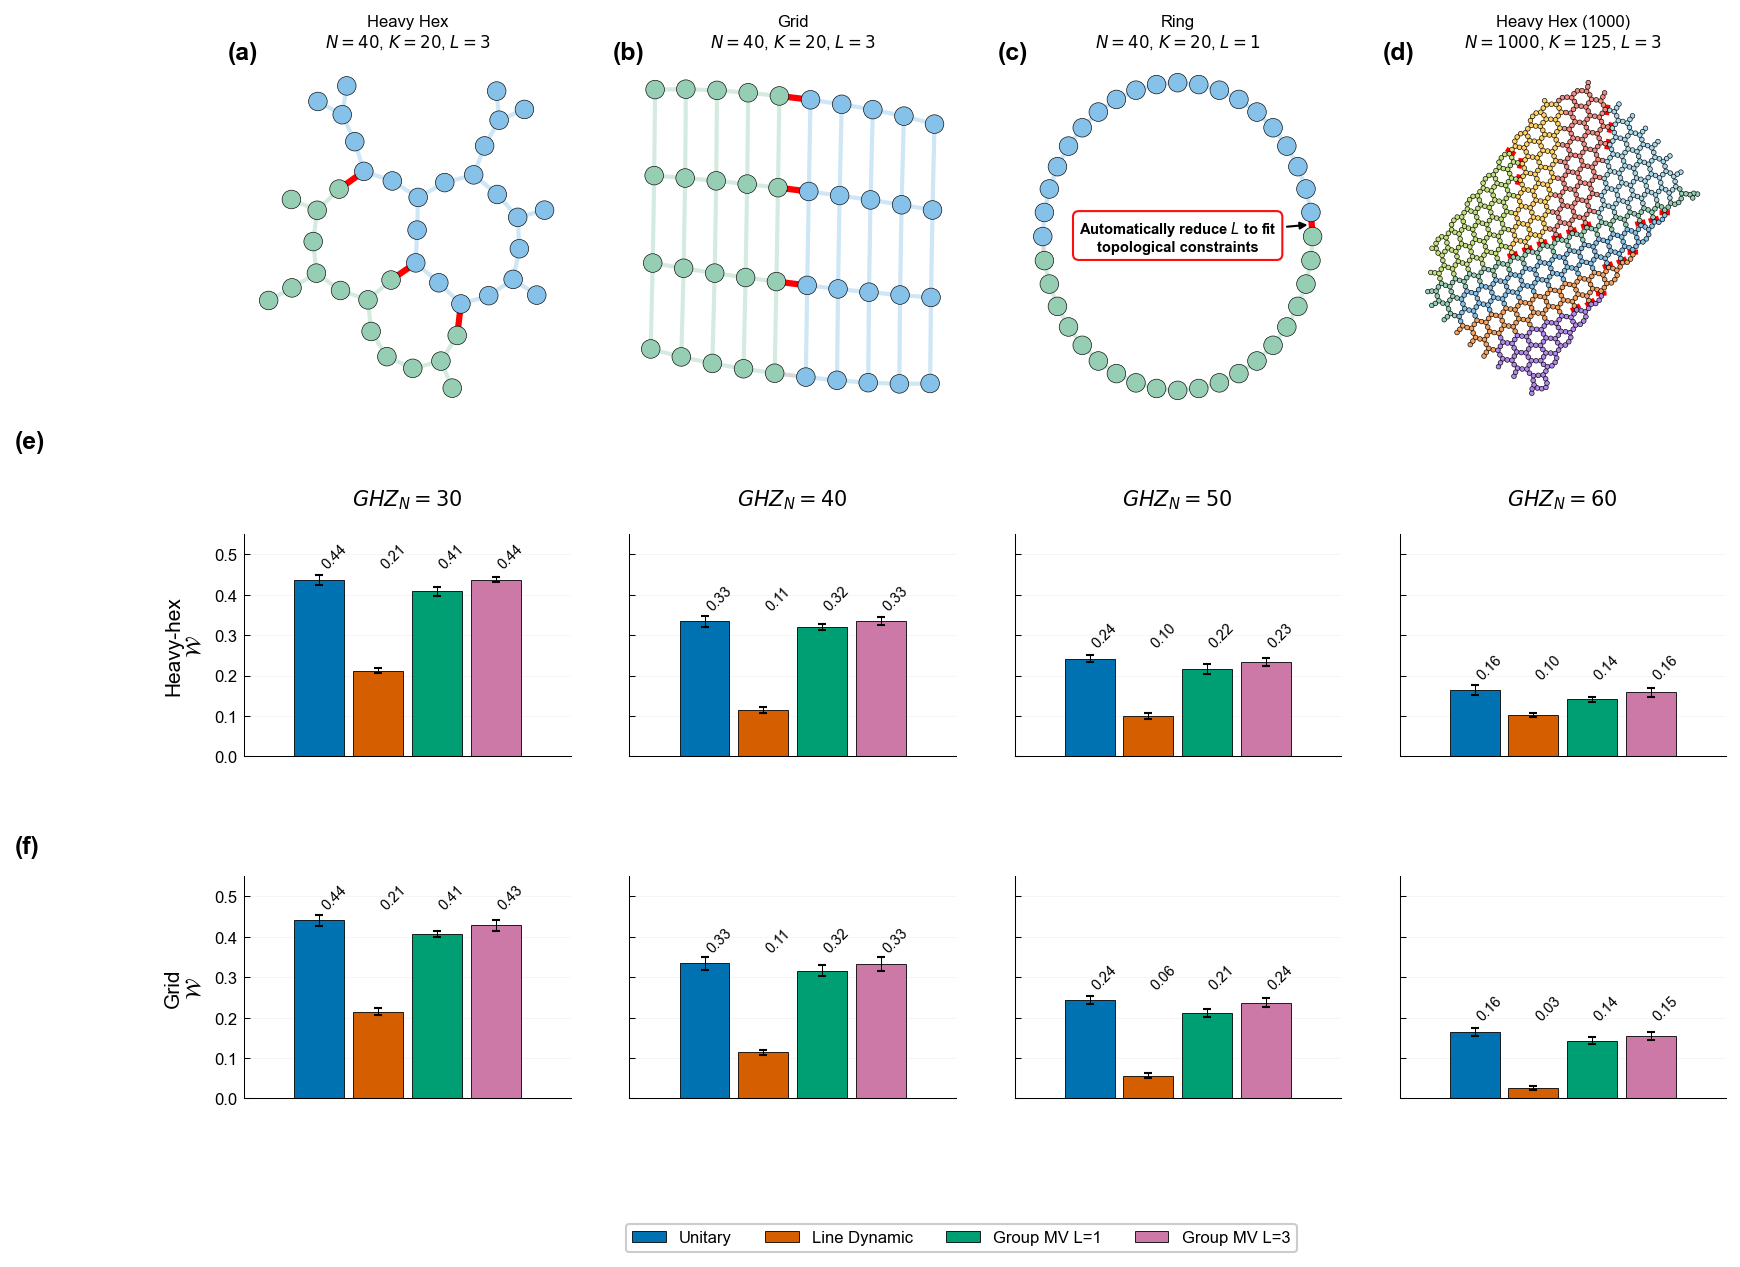

Saved figures/repro_figure2.{pdf,png}
Wrote figures/repro_figure2_data_full.json


In [ ]:
# Aggregate witness trials (was old cell 30 logic) and produce the combined
# 6-panel figure (a-d topology partitions + e-f witness bar charts).
import numpy as _np

results_agg = {}
for (topo, n_val, mname), trials in all_trials.items():
    w = [t["witness"] for t in trials]
    results_agg[(topo, n_val, mname)] = {
        "witness_mean": float(_np.mean(w)),
        "witness_err": float(_np.std(w, ddof=1)) if len(w) > 1 else 0.0,
        "n_trials": len(w),
    }

# ── Combined figure: 3 rows x 4 cols ──
# Row 0: topology partitions (a-d) — uses gridspec to span row
# Rows 1-2: bar charts (e on row 1, f on row 2)
fig = plt.figure(figsize=(DOUBLE_COL * 1.8, 9))
gs = GridSpec(3, 4, figure=fig,
               height_ratios=[1.6, 1.0, 1.0],
               hspace=0.45, wspace=0.18)

# ── Top row: panels (a)-(d) — topology partitions ──
for col_idx, p in enumerate(_panel_data):
    ax = fig.add_subplot(gs[0, col_idx])
    ns = 80 if p["n"] <= 60 else 5
    title = f"{p['name']}\n$N={p['n']}$, $K={p['k']}$, $L={p['L']}$"
    visualize_groups(p["G_hw"], p["groups"], p["b_edges"],
                       boundary_info=p["b_info"], title=title, ax=ax,
                       layout_fn=p["layout_fn"], node_size=ns)
    # Panel label (a)/(b)/(c)/(d)
    ax.text(-0.05, 1.05, "(" + chr(97 + col_idx) + ")",
             transform=ax.transAxes, fontsize=12, fontweight="bold", va="top")

    # Ring auto-reduce annotation
    if p["name"] == "Ring" and p["b_info"]:
        G_sub = p["G_hw"].subgraph(set().union(*p["groups"]))
        pos_ring = p["layout_fn"](G_sub)
        all_pts = _np.array([pos_ring[q] for q in G_sub.nodes() if q in pos_ring])
        cx, cy = all_pts.mean(axis=0)
        for (ga, gb), info in p["b_info"].items():
            links = info.get("links", [])
            if links:
                qa, qb = links[0]
                if qa in pos_ring and qb in pos_ring:
                    bx = (pos_ring[qa][0] + pos_ring[qb][0]) / 2
                    by = (pos_ring[qa][1] + pos_ring[qb][1]) / 2
                    ax.annotate("Automatically reduce $L$ to fit\ntopological constraints",
                                  xy=(bx, by), xytext=(cx, cy),
                                  fontsize=7, fontweight="bold", ha="center", va="center",
                                  arrowprops=dict(arrowstyle="-|>", color="black", lw=1),
                                  bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                                            edgecolor="red", alpha=0.95), wrap=True)
                    break

# ── Bottom rows: panels (e)-(f) — witness bar charts ──
N_BAR = N_VALUES   # [30, 40, 50, 60] from setup cell
TOPOS_BAR = TOPO_NAMES  # ["Heavy-hex", "Grid"]

bar_width = 0.18
first_ax_per_row = {}
ax_grid = {}
for ri, topo_name in enumerate(TOPOS_BAR):
    row_idx = 1 + ri
    for ci, n_val in enumerate(N_BAR):
        if ci == 0:
            ax = fig.add_subplot(gs[row_idx, ci])
            first_ax_per_row[row_idx] = ax
        else:
            ax = fig.add_subplot(gs[row_idx, ci], sharey=first_ax_per_row[row_idx])
        ax_grid[(row_idx, ci)] = ax

        methods_here, fids, errs, colors = [], [], [], []
        for mname in METHOD_NAMES:
            key = (topo_name, n_val, mname)
            if key in results_agg:
                methods_here.append(mname)
                fids.append(results_agg[key]["witness_mean"])
                errs.append(results_agg[key]["witness_err"])
                colors.append(METHOD_COLORS[mname])
        if not methods_here:
            ax.set_visible(False); continue

        x_pos = _np.arange(len(methods_here)) * bar_width
        x_pos = x_pos - x_pos.mean()
        bars = ax.bar(x_pos, fids, bar_width * 0.85, yerr=errs, capsize=2,
                       color=colors, edgecolor="black", linewidth=0.4,
                       error_kw={"linewidth": 0.5})
        ax.set_xlim(-0.5, 0.5); ax.set_xticks([])
        if row_idx == 1:
            ax.set_title(f"$GHZ_N={n_val}$", fontsize=10, pad=14)
        if ci == 0:
            ax.set_ylabel(f"{topo_name}\n" + r"$\mathcal{W}$", fontsize=10)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_ylim(0, 0.55)
        ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
        if ci > 0:
            plt.setp(ax.get_yticklabels(), visible=False)
        ax.yaxis.grid(True, alpha=0.2, linewidth=0.3)
        ax.set_axisbelow(True)
        ax.tick_params(labelsize=8)

        # Fidelity labels above bars (rotated)
        max_fid = max(fids) if fids else 0
        for bar_obj, fid_val in zip(bars, fids):
            ax.text(bar_obj.get_x() + bar_obj.get_width() / 2,
                     max_fid + 0.02, f"{fid_val:.2f}",
                     ha="left", va="bottom", fontsize=7, rotation=45)

# Row labels (e), (f)
fig.text(0.005, 0.605, "(e)", fontsize=12, fontweight="bold", va="top")
fig.text(0.005, 0.305, "(f)", fontsize=12, fontweight="bold", va="top")

# Method legend at bottom
legend_handles = [plt.Rectangle((0, 0), 1, 1,
                                  facecolor=METHOD_COLORS[m],
                                  edgecolor="black", linewidth=0.4)
                   for m in METHOD_NAMES]
fig.legend(legend_handles, METHOD_NAMES,
            loc="lower center", ncol=4, fontsize=8,
            bbox_to_anchor=(0.5, -0.01), frameon=True, edgecolor="0.8")

os.makedirs("figures", exist_ok=True)
fig.savefig("figures/repro_figure2.pdf", bbox_inches="tight", dpi=600)
fig.savefig("figures/repro_figure2.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved figures/repro_figure2.{pdf,png}")


# Persist aggregated witness data for `tests/test_against_paper.py`.
import json as _json
_data_path = os.path.join("figures", f"repro_figure2_data_{MODE}.json")
os.makedirs("figures", exist_ok=True)
with open(_data_path, "w") as _f:
    _json.dump({
        "mode": MODE,
        "params": {
            "N_VALUES": N_VALUES, "TOPO_NAMES": TOPO_NAMES,
            "GROUP_SIZE": GROUP_SIZE, "N_TRIALS": N_TRIALS,
            "SHOTS_WITNESS": SHOTS_WITNESS, "SEED_POOL_SIZE": SEED_POOL_SIZE,
            "P_CX": P_CX, "P_1Q": P_1Q, "P_RO": P_RO,
            "BASE_SEED": BASE_SEED,
        },
        "aggregated": {
            f"{topo}|{n_val}|{method}": v
            for (topo, n_val, method), v in results_agg.items()
        },
    }, _f, indent=2)
print(f"Wrote {_data_path}")


## 15. Fidelity validation table ($N=30$, Heavy-hex)

We estimate state fidelity via stabilizer sampling on
Heavy-hex with $N=30$ for three methods (Unitary, Line Dynamic, Group-MV
$L=3$). M3 mitigation is disabled here so the estimator measures the
intrinsic state fidelity (rather than its M3-corrected counterpart used
in the witness sweep). The relative ordering should match the witness
comparison: Group-MV $\geq$ Unitary $>$ Line Dynamic.

In [ ]:
_cm_table = cm_hh_default
_N_table = 30
_pool_table_l3 = _seed_pools.get(("Heavy-hex", 30), {}).get("l3", [])
_seed_l3 = _pool_table_l3[0] if _pool_table_l3 else BASE_SEED

_circ_u, _ghz_u = prepare_unitary_ghz(_cm_table, _N_table, seed=BASE_SEED)
_circ_ld, _ghz_ld = build_line_dynamic_on_coupling_map(_cm_table, _N_table)
_groups_l3, _ = partition_into_groups(_cm_table, _N_table, GROUP_SIZE, seed=_seed_l3)
_circ_g3, _ghz_g3, _ = build_group_ghz(_cm_table, _groups_l3, L=3, seed=BASE_SEED)

_nm_table = make_paper_noise_model()

print(f"Running stabilizer fidelity (M={MC_SAMPLES_FID}, shots={MC_SHOTS_FID}, M3=off) ...")
t_tab = time.time()
_rows = []
for mname, circ, ghz in [
    ("Unitary",        _circ_u,  _ghz_u),
    ("Line Dynamic",   _circ_ld, _ghz_ld),
    ("Group MV L=3",   _circ_g3, _ghz_g3),
]:
    r = mc_ghz_fidelity(circ, len(ghz), ghz,
                         noise_model=_nm_table,
                         m3_mitigate=False,
                         seed=BASE_SEED)
    _rows.append((mname, r["fidelity"], r["std_error"]))
    print(f"  {mname:14s}  F = {r['fidelity']:.4f} +/- {r['std_error']:.4f}")
print(f"Total time: {time.time() - t_tab:.1f}s")

# Render as a compact pandas DataFrame
df_table = pd.DataFrame(
    [(m, f"{F:.3f} $\\pm$ {se:.3f}") for m, F, se in _rows],
    columns=["Method", f"Fidelity (N={_N_table}, Heavy-hex, mode={MODE!r})"])
df_table


# Persist fidelity-validation results for `tests/test_against_paper.py`.
import json as _json
_fid_path = os.path.join("figures", "repro_fidelity_validation.json")
os.makedirs("figures", exist_ok=True)
_save = {m: {"fidelity": F, "std_error": se} for (m, F, se) in _rows}
with open(_fid_path, "w") as _f:
    _json.dump(_save, _f, indent=2)
print(f"Wrote {_fid_path}")


Running stabilizer fidelity (M=100, shots=2048, M3=off) ...


  Unitary         F = 0.1248 +/- 0.0103


  Line Dynamic    F = 0.0573 +/- 0.0050


  Group MV L=3    F = 0.1215 +/- 0.0103
Total time: 28.5s
Wrote figures/repro_fidelity_validation.json


## 16. Noise-free correctness check

Sanity check that the Group-MV circuit produces a valid $|\mathrm{GHZ}_N\rangle$ when noise is absent — the emitted state should have weight only on $|0\ldots 0\rangle$ and $|1\ldots 1\rangle$. We use an $N=8$ instance on a fully-connected 8-qubit fabric so all partitionings are feasible.

In [ ]:
# A cautious test: unitary LOG is trivially correct; the interesting tests are
# the dynamic circuits, which route through mid-circuit measurement and
# classical conditioning. AerSimulator handles these via method='automatic'.
_N_VER = 8
_cm_ver = CouplingMap.from_full(_N_VER)
_sim_sv = AerSimulator(method='automatic')


def _check_is_ghz(circ, ghz_qubits, label, shots=4000):
    """Run without noise; a correct GHZ gives P(|0...0> on ghz_qubits) + P(|1...1>) = 1."""
    qc = circ.copy()
    cr = ClassicalRegister(len(ghz_qubits), 'out')
    qc.add_register(cr)
    for i, q in enumerate(sorted(ghz_qubits)):
        qc.measure(q, cr[i])
    counts = _sim_sv.run(qc, shots=shots).result().get_counts()
    out = _marginalize_out(counts)
    n = len(ghz_qubits)
    p = (out.get('0' * n, 0) + out.get('1' * n, 0)) / shots
    ok = p > 0.98
    print(f"  {'PASS' if ok else 'FAIL'}  {label}: P(|0^N>+|1^N>) = {p:.4f}")
    return ok


print(f"Correctness check (N={_N_VER}, noise-free):")
_circ_u8, _ghz_u8 = prepare_unitary_ghz(_cm_ver, _N_VER, seed=BASE_SEED)
_check_is_ghz(_circ_u8, _ghz_u8, "Unitary (LOG tree)")

_circ_ld8, _ghz_ld8 = build_line_dynamic_on_coupling_map(_cm_ver, _N_VER)
_check_is_ghz(_circ_ld8, _ghz_ld8, "Line Dynamic")

for _L in (1, 3):
    _groups8, _ = partition_into_groups(_cm_ver, _N_VER, group_size=4, seed=BASE_SEED)
    _circ8, _ghz8, _bi8 = build_group_ghz(_cm_ver, _groups8, L=_L, seed=BASE_SEED)
    _min_leff8 = min((i["L_eff"] for i in _bi8.values()), default=1)
    _check_is_ghz(_circ8, _ghz8,
                  f"Group-MV L={_L}, min L_eff={_min_leff8}")


Correctness check (N=8, noise-free):
  PASS  Unitary (LOG tree): P(|0^N>+|1^N>) = 1.0000
  PASS  Line Dynamic: P(|0^N>+|1^N>) = 1.0000
  PASS  Group-MV L=1, min L_eff=1: P(|0^N>+|1^N>) = 1.0000
  PASS  Group-MV L=3, min L_eff=3: P(|0^N>+|1^N>) = 1.0000


## 17. Appendix — caveats

- **M3 calibration cost.** `mthree.M3Mitigation.cals_from_system` is run once per (topology, $N$, trial) in Section 14. With stabilizer simulation this takes ~1 s per call even at $N=60$.
- **Seed reproducibility.** Partitioning uses KL bisection with a fixed seed; different Qiskit/NetworkX versions may route the KL tie-breaking differently. The qualitative ordering (Group-MV $L=3$ $\geq$ $L=1$ $\geq$ Line Dynamic, with all three above the $\mathcal{W}=0.5$ threshold at small $N$) is version-insensitive.
- **Dynamic-circuit simulator requirement.** Line-Dynamic and Group-MV both use `qc.if_test(...)` classical conditioning. AerSimulator's `'stabilizer'` method handles these natively when the conditioned gates are Clifford, which is the case here (only `x` is conditioned).
